In [1]:
import numpy as np
import matplotlib.pyplot as plt
from reservoirpy.nodes import Reservoir, Ridge
import reservoirpy

# Reproducibility
reservoirpy.set_seed(42)
np.random.seed(42)

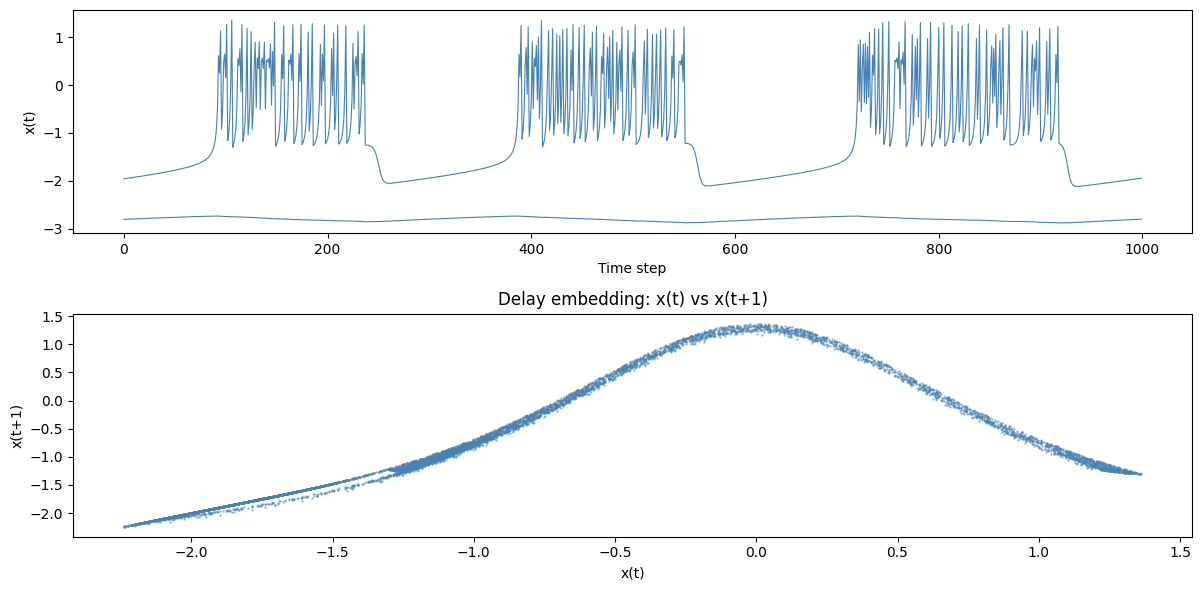

In [13]:
dataset = np.loadtxt('../data/chaotic_data/rulkov_map.csv', delimiter=',')

# Visualize the chaotic time series
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(dataset[:1000], color='steelblue', linewidth=0.8)
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('x(t)')

# Delay embedding to show the attractor
delay = 1
axes[1].scatter(dataset[:-delay, 0], dataset[delay:, 0], s=0.5, alpha=0.5, color='steelblue')
axes[1].set_title(f'Delay embedding: x(t) vs x(t+{delay})')
axes[1].set_xlabel('x(t)')
axes[1].set_ylabel(f'x(t+{delay})')

plt.tight_layout()
plt.show()

In [14]:
data = dataset[:, 0].reshape(-1, 1)  # use one component for ESN

In [15]:
X = data[:-1]   # x(t)     : shape (4999, 1)
Y = data[1:]    # x(t+1)   : shape (4999, 1)

train_len = 2000
X_train, Y_train = X[:train_len], Y[:train_len]
X_test,  Y_test  = X[train_len:], Y[train_len:]

reservoir = Reservoir(
    units=500,
    sr=0.95,
    lr=0.3,
    input_scaling=0.1,
    rc_connectivity=0.1,
    seed=42)
readout = Ridge(ridge=1e-6)
esn = reservoir >> readout

predictions_train = esn.fit(X_train, Y_train, warmup=100)

# Free-run prediction
pred_len = 500

# First, warm up the reservoir with some true data to set the internal state
warmup_data = X_test[:200]
_ = esn.run(warmup_data)

# Now do free-run: feed prediction back as input
Y_pred = []
current_input = X_test[200:201]  # start from a true data point

for step in range(pred_len):
    pred = esn.run(current_input)  # predict next step
    pred = np.array(pred).reshape(1, -1)
    Y_pred.append(pred[0, 0])
    current_input = pred            # feed prediction back

Y_pred = np.array(Y_pred)
Y_true = Y_test[200:200+pred_len, 0]

# Compute error metrics
rmse = np.sqrt(np.mean((Y_true - Y_pred.reshape(-1, 1))**2))
nrmse = rmse / np.std(Y_true)
print(f"  RMSE:  {rmse:.6f}")
print(f"  NRMSE: {nrmse:.6f}")

  RMSE:  384.809437
  NRMSE: 374.712247


In [17]:
# ============================================================
# ESN Hyperparameter Grid Search — Closed-Loop Prediction
# ============================================================

import numpy as np
import itertools
import time
from reservoirpy.nodes import Reservoir, Ridge
import reservoirpy

reservoirpy.set_seed(42)

# ----------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------
dataset = np.loadtxt('../data/chaotic_data/rulkov_map.csv', delimiter=',')
data = dataset[:, 0].reshape(-1, 1)

X = data[:-1]
Y = data[1:]

train_len = 2000
washout_len = 200   # true-data washout before closed-loop
pred_len = 500      # closed-loop prediction length

X_train, Y_train = X[:train_len], Y[:train_len]
X_test,  Y_test  = X[train_len:], Y[train_len:]
Y_true = Y_test[washout_len:washout_len + pred_len, 0]

# ----------------------------------------------------------
# 2. DEFINE PARAMETER GRID
# ----------------------------------------------------------
param_grid = {
    'units':           [300, 500, 800],
    'sr':              [0.9, 0.95, 0.99, 1.2, 1.3],
    'lr':              [0.1, 0.3, 0.5, 1.0],
    'input_scaling':   [0.05, 0.1, 0.5],
    'ridge':           [1e-8, 1e-6, 1e-4, 1e-2],
}

# Generate all combinations
keys = list(param_grid.keys())
combos = list(itertools.product(*[param_grid[k] for k in keys]))
print(f"Total combinations to evaluate: {len(combos)}")

# ----------------------------------------------------------
# 3. EVALUATION FUNCTION
# ----------------------------------------------------------
def evaluate_esn(units, sr, lr, input_scaling, ridge, seed=42):
    """
    Build, train, and evaluate one ESN configuration.
    Returns NRMSE on closed-loop prediction.
    """
    try:
        reservoir = Reservoir(
            units=int(units),
            sr=sr,
            lr=lr,
            input_scaling=input_scaling,
            rc_connectivity=0.1,
            seed=seed
        )
        readout = Ridge(ridge=ridge)
        esn = reservoir >> readout

        # Train
        esn.fit(X_train, Y_train, warmup=100)

        # Washout with true test data
        esn.run(X_test[:washout_len])

        # Closed-loop prediction
        Y_pred = []
        current_input = X_test[washout_len:washout_len + 1]
        for _ in range(pred_len):
            pred = esn.run(current_input)
            pred = np.array(pred).reshape(1, -1)
            Y_pred.append(pred[0, 0])
            current_input = pred

        Y_pred = np.array(Y_pred)

        # Check for divergence (NaN or explosion)
        if np.any(np.isnan(Y_pred)) or np.max(np.abs(Y_pred)) > 1e6:
            return np.inf

        rmse = np.sqrt(np.mean((Y_true - Y_pred) ** 2))
        nrmse = rmse / np.std(Y_true)
        return nrmse

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf

# ----------------------------------------------------------
# 4. RUN GRID SEARCH
# ----------------------------------------------------------
results = []
best_nrmse = np.inf
best_params = None

t_start = time.time()

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse = evaluate_esn(**params)
    results.append({**params, 'nrmse': nrmse})

    # Track best
    if nrmse < best_nrmse:
        best_nrmse = nrmse
        best_params = params.copy()

    # Progress update every 20 trials
    if (i + 1) % 20 == 0 or (i + 1) == len(combos):
        elapsed = time.time() - t_start
        print(f"  [{i+1}/{len(combos)}]  elapsed: {elapsed:.0f}s  "
              f"current best NRMSE: {best_nrmse:.6f}")

total_time = time.time() - t_start

# ----------------------------------------------------------
# 5. RESULTS
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("GRID SEARCH COMPLETE")
print(f"Total time: {total_time:.1f}s  ({total_time/len(combos):.2f}s per trial)")
print(f"Best NRMSE: {best_nrmse:.6f}")
print(f"Best parameters:")
for k, v in best_params.items():
    print(f"  {k:20s} = {v}")
print("=" * 60)

# ----------------------------------------------------------
# 6. TOP 10 CONFIGURATIONS
# ----------------------------------------------------------
results_sorted = sorted(results, key=lambda r: r['nrmse'])

print("\nTop 10 configurations:")
print(f"{'Rank':>4}  {'units':>5}  {'sr':>5}  {'lr':>4}  {'in_sc':>5}  "
      f"{'ridge':>8}  {'NRMSE':>10}")
print("-" * 55)
for rank, r in enumerate(results_sorted[:10], 1):
    print(f"{rank:4d}  {int(r['units']):5d}  {r['sr']:5.2f}  {r['lr']:4.1f}  "
          f"{r['input_scaling']:5.2f}  {r['ridge']:8.1e}  {r['nrmse']:10.6f}")

Total combinations to evaluate: 720
  [20/720]  elapsed: 1s  current best NRMSE: 0.784209
  [40/720]  elapsed: 2s  current best NRMSE: 0.784209
  [60/720]  elapsed: 3s  current best NRMSE: 0.773024
  [80/720]  elapsed: 4s  current best NRMSE: 0.773024
  [100/720]  elapsed: 5s  current best NRMSE: 0.758316
  [120/720]  elapsed: 6s  current best NRMSE: 0.758316
  [140/720]  elapsed: 7s  current best NRMSE: 0.758316
  [160/720]  elapsed: 8s  current best NRMSE: 0.758316
  [180/720]  elapsed: 10s  current best NRMSE: 0.758316
  [200/720]  elapsed: 11s  current best NRMSE: 0.758316
  [220/720]  elapsed: 12s  current best NRMSE: 0.758316
  [240/720]  elapsed: 13s  current best NRMSE: 0.758316
  [260/720]  elapsed: 14s  current best NRMSE: 0.758316
  [280/720]  elapsed: 16s  current best NRMSE: 0.758316
  [300/720]  elapsed: 18s  current best NRMSE: 0.758316
  [320/720]  elapsed: 20s  current best NRMSE: 0.758316
  [340/720]  elapsed: 22s  current best NRMSE: 0.758316
  [360/720]  elapsed: 23